In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
data=pd.read_csv(r"C:\Users\snehi\Downloads\2019-Nov.csv.zip",nrows=10000)

In [15]:
print(data.head())

                event_time event_type  product_id          category_id  \
0  2019-11-01 00:00:00 UTC       view     1003461  2053013555631882655   
1  2019-11-01 00:00:00 UTC       view     5000088  2053013566100866035   
2  2019-11-01 00:00:01 UTC       view    17302664  2053013553853497655   
3  2019-11-01 00:00:01 UTC       view     3601530  2053013563810775923   
4  2019-11-01 00:00:01 UTC       view     1004775  2053013555631882655   

               category_code   brand   price    user_id  \
0     electronics.smartphone  xiaomi  489.07  520088904   
1  appliances.sewing_machine  janome  293.65  530496790   
2                        NaN   creed   28.31  561587266   
3  appliances.kitchen.washer      lg  712.87  518085591   
4     electronics.smartphone  xiaomi  183.27  558856683   

                           user_session  
0  4d3b30da-a5e4-49df-b1a8-ba5943f1dd33  
1  8e5f4f83-366c-4f70-860e-ca7417414283  
2  755422e7-9040-477b-9bd2-6a6e8fd97387  
3  3bfb58cd-7892-48cc-8020-2f17e

In [16]:
print(data.columns)

Index(['event_time', 'event_type', 'product_id', 'category_id',
       'category_code', 'brand', 'price', 'user_id', 'user_session'],
      dtype='object')


In [17]:
print(data["event_type"].value_counts())

event_type
view        9805
purchase     102
cart          93
Name: count, dtype: int64


In [18]:
print(data.isnull().sum())

event_time          0
event_type          0
product_id          0
category_id         0
category_code    3741
brand            1805
price               0
user_id             0
user_session        0
dtype: int64


In [19]:
print("Rows:", len(data))
print("Columns:", len(data.columns))

Rows: 10000
Columns: 9


In [20]:
view_users = data[data["event_type"] == "view"]["user_id"].nunique()
cart_users = data[data["event_type"] == "cart"]["user_id"].nunique()
purchase_users = data[data["event_type"] == "purchase"]["user_id"].nunique()

print("Unique viewers:", view_users)
print("Unique cart users:", cart_users)
print("Unique purchasers:", purchase_users)

Unique viewers: 2118
Unique cart users: 60
Unique purchasers: 79


In [21]:
view_to_cart = (cart_users / view_users * 100) if view_users else 0
cart_to_purchase = (purchase_users / cart_users * 100) if cart_users else 0
overall_conversion = (purchase_users / view_users * 100) if view_users else 0

print("View to Cart Conversion:", round(view_to_cart, 2), "%")
print("Cart to Purchase Conversion:", round(cart_to_purchase, 2), "%")
print("View to Purchase Conversion:", round(overall_conversion, 2), "%")

View to Cart Conversion: 2.83 %
Cart to Purchase Conversion: 131.67 %
View to Purchase Conversion: 3.73 %


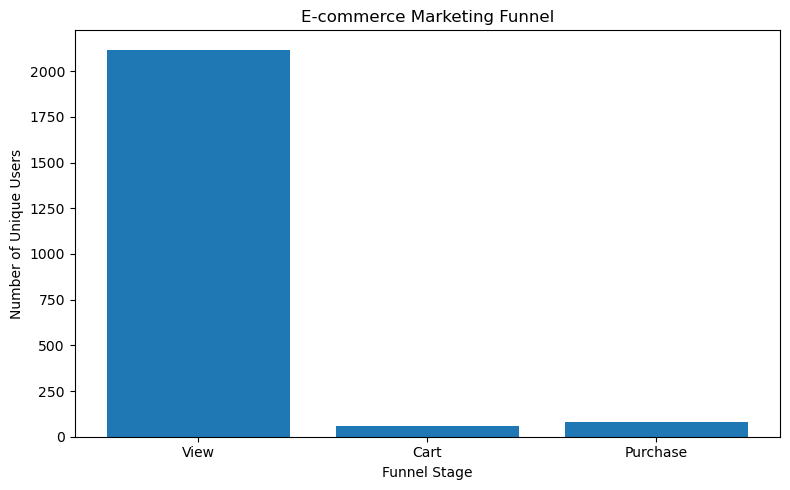

In [22]:
import matplotlib.pyplot as plt

stages = ["View", "Cart", "Purchase"]
counts = [view_users, cart_users, purchase_users]

plt.figure(figsize=(8, 5))
plt.bar(stages, counts)
plt.title("E-commerce Marketing Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Unique Users")
plt.tight_layout()
plt.show()

In [23]:
view_sessions = data[data["event_type"] == "view"]["user_session"].nunique()

cart_sessions = data[data["event_type"] == "cart"]["user_session"].nunique()

purchase_sessions = data[data["event_type"] == "purchase"]["user_session"].nunique()

print("View Sessions:", view_sessions)
print("Cart Sessions:", cart_sessions)
print("Purchase Sessions:", purchase_sessions)

View Sessions: 2449
Cart Sessions: 61
Purchase Sessions: 80


In [24]:
view_to_cart = cart_sessions / view_sessions * 100 if view_sessions else 0

view_to_purchase = purchase_sessions / view_sessions * 100 if view_sessions else 0

print("View to Cart Conversion:", round(view_to_cart, 2), "%")
print("View to Purchase Conversion:", round(view_to_purchase, 2), "%")

View to Cart Conversion: 2.49 %
View to Purchase Conversion: 3.27 %


In [26]:
session_funnel = data.groupby("user_session").agg(
    viewed=("event_type", lambda x: (x == "view").any()),
    added_to_cart=("event_type", lambda x: (x == "cart").any()),
    purchased=("event_type", lambda x: (x == "purchase").any())
)

view_to_cart_sessions = session_funnel[
    session_funnel["viewed"] & session_funnel["added_to_cart"]
]

cart_to_purchase_sessions = session_funnel[
    session_funnel["added_to_cart"] & session_funnel["purchased"]
]

print("Sessions with views:", session_funnel["viewed"].sum())
print("Sessions with views and cart:", len(view_to_cart_sessions))
print("Sessions with cart and purchase:", len(cart_to_purchase_sessions))

Sessions with views: 2449
Sessions with views and cart: 60
Sessions with cart and purchase: 29


In [27]:

view_sessions = session_funnel["viewed"].sum()

view_cart = (
    session_funnel["viewed"] &
    session_funnel["added_to_cart"]
).sum()

view_cart_purchase = (
    session_funnel["viewed"] &
    session_funnel["added_to_cart"] &
    session_funnel["purchased"]
).sum()

print("Sessions with views:", view_sessions)
print("Sessions with views and cart:", view_cart)
print("Sessions with view, cart and purchase:", view_cart_purchase)

Sessions with views: 2449
Sessions with views and cart: 60
Sessions with view, cart and purchase: 29


In [28]:
view_to_cart = view_cart / view_sessions * 100 if view_sessions else 0

cart_to_purchase = (
    view_cart_purchase / view_cart * 100 if view_cart else 0
)

overall_conversion = (
    view_cart_purchase / view_sessions * 100 if view_sessions else 0
)

print("View to Cart:", round(view_to_cart, 2), "%")
print("Cart to Purchase:", round(cart_to_purchase, 2), "%")
print("Overall Funnel Conversion:", round(overall_conversion, 2), "%")

View to Cart: 2.45 %
Cart to Purchase: 48.33 %
Overall Funnel Conversion: 1.18 %


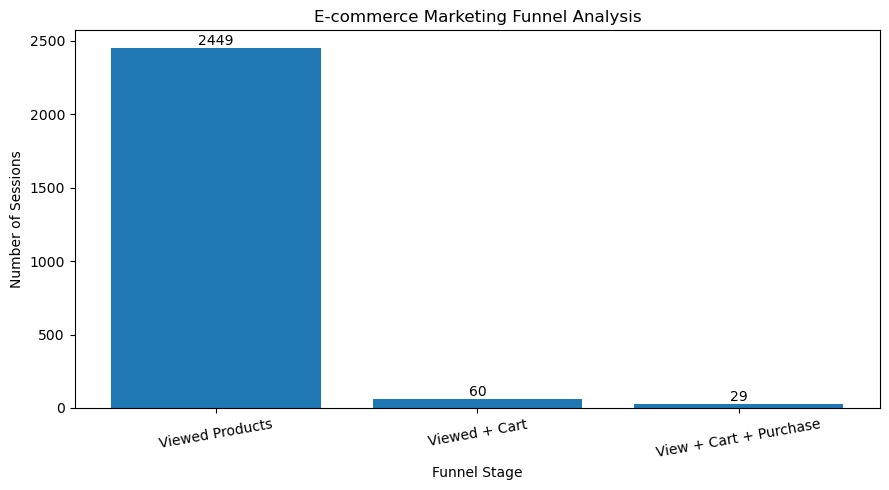

In [29]:

stages = ["Viewed Products", "Viewed + Cart", "View + Cart + Purchase"]
counts = [view_sessions, view_cart, view_cart_purchase]

plt.figure(figsize=(9, 5))
bars = plt.bar(stages, counts)

plt.title("E-commerce Marketing Funnel Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=10)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

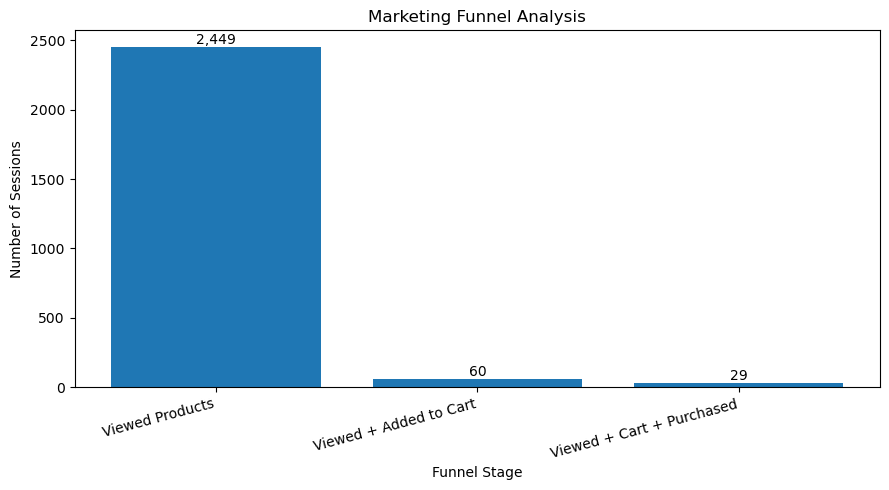

In [30]:

stages = [
    "Viewed Products",
    "Viewed + Added to Cart",
    "Viewed + Cart + Purchased"
]

counts = [
    view_sessions,
    view_cart,
    view_cart_purchase
]

plt.figure(figsize=(9, 5))
bars = plt.bar(stages, counts)

plt.title("Marketing Funnel Analysis")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=15, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Funnel Analysis – Key Observations

1. A total of 2,449 sessions included product views.
2. Only 60 sessions included both product views and cart additions, giving a view-to-cart conversion rate of 2.45%.
3. Of those 60 sessions, 29 included product views, cart additions, and purchases, giving a cart-to-purchase conversion rate of 48.33%.
4. The overall conversion rate for sessions containing all three event types was 1.18%.
5. The largest drop-off occurred between viewing products and adding items to the cart.

**Recommendation:** Improve product pages by providing clearer product information, competitive pricing, customer reviews, and visible add-to-cart buttons.

**Note:** These are preliminary findings from the first 10,000 rows of the dataset. Further analysis on a larger dataset is needed before drawing final conclusions.


In [33]:

event_counts = data["event_type"].value_counts()

print("Event Type Counts:")
print(event_counts)


event_percentages = data["event_type"].value_counts(normalize=True) * 100

print("\nEvent Type Percentages:")
print(event_percentages.round(2))

Event Type Counts:
event_type
view        9805
purchase     102
cart          93
Name: count, dtype: int64

Event Type Percentages:
event_type
view        98.05
purchase     1.02
cart         0.93
Name: proportion, dtype: float64


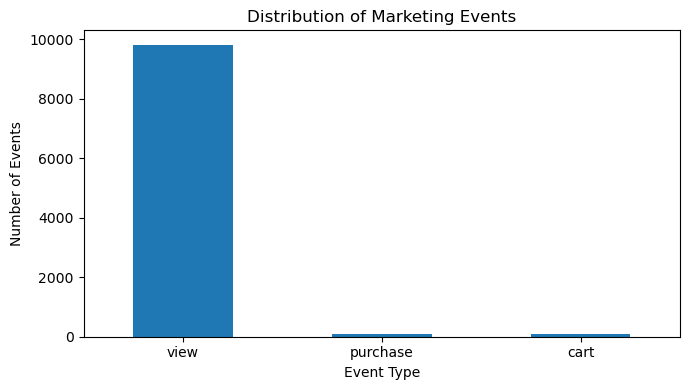

In [34]:
event_counts.plot(kind="bar", figsize=(7, 4))

plt.title("Distribution of Marketing Events")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Event Distribution – Key Observations

* Product views represent the browsing activity in the dataset.
* Cart events indicate users who show purchase interest by adding products to their carts.
* Purchase events represent completed transactions.
* Comparing these event counts helps identify differences between browsing activity and purchasing activity.

**Note:** The analysis uses the first 10,000 rows of the dataset, so these results are preliminary.


In [35]:

event_summary = pd.DataFrame({
    "Event Type": event_counts.index,
    "Event Count": event_counts.values,
    "Percentage": event_percentages.values.round(2)
})

# Display the summary
display(event_summary)

# Save the summary as a CSV file
event_summary.to_csv("event_summary.csv", index=False)

print("File saved successfully as event_summary.csv")


,Event Type,Event Count,Percentage
0,view,9805,98.05
1,purchase,102,1.02
2,cart,93,0.93


File saved successfully as event_summary.csv


In [36]:

category_analysis = data.groupby(
    ["category_code", "event_type"]
).size().reset_index(name="event_count")


category_analysis = category_analysis.sort_values(
    by="event_count", ascending=False
)

display(category_analysis.head(15))

,category_code,event_type,event_count
95,electronics.smartphone,view,2013
102,electronics.video.tv,view,280
92,electronics.clocks,view,269
19,appliances.environment.vacuum,view,234
83,electronics.audio.headphone,view,224
37,appliances.kitchen.refrigerators,view,204
110,furniture.living_room.cabinet,view,203
63,computers.notebook,view,201
40,appliances.kitchen.washer,view,199
7,apparel.shoes,view,187


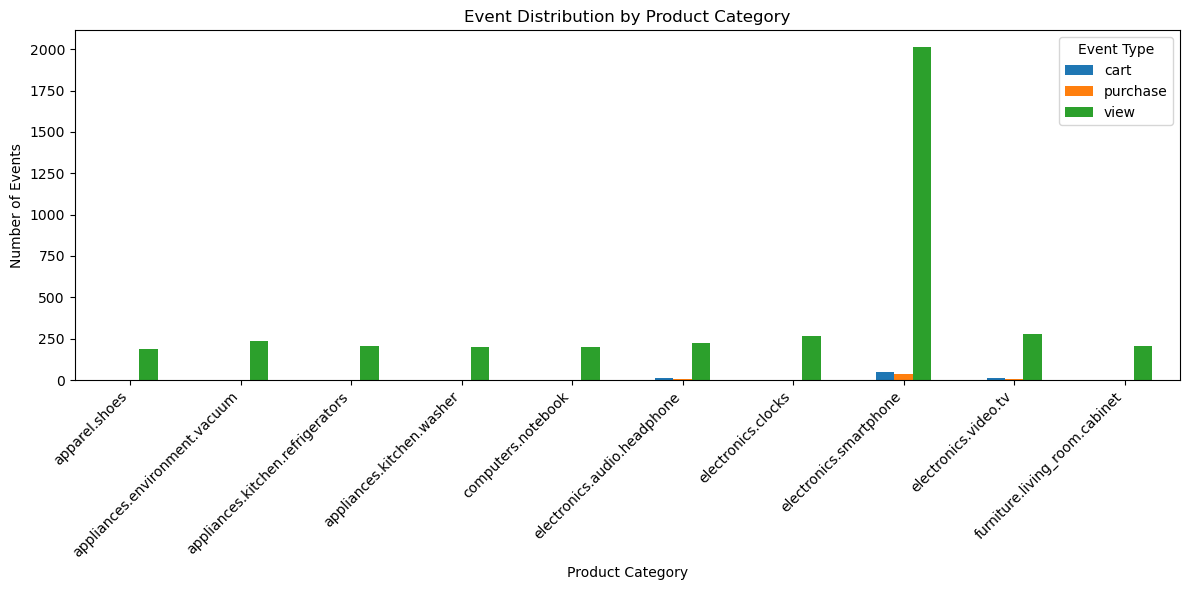

In [38]:

top_categories = (
    data.groupby("category_code")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

category_data = data[data["category_code"].isin(top_categories)]

category_chart = pd.crosstab(
    category_data["category_code"],
    category_data["event_type"]
)

category_chart.plot(kind="bar", figsize=(12, 6))

plt.title("Event Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Events")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Event Type")
plt.tight_layout()
plt.show()

In [39]:

brand_analysis = data.groupby(
    ["brand", "event_type"]
).size().reset_index(name="event_count")

top_brands = (
    data.dropna(subset=["brand"])
    .groupby("brand")
    .size()
    .sort_values(ascending=False)
    .head(10)
    .index
)

brand_summary = brand_analysis[
    brand_analysis["brand"].isin(top_brands)
]

display(
    brand_summary.sort_values(
        by="event_count", ascending=False
    )
)

,brand,event_type,event_count
570,samsung,view,962
36,apple,view,757
699,xiaomi,view,624
291,huawei,view,174
379,lucente,view,166
602,sony,view,141
618,sv,view,131
96,bosch,view,120
555,rondell,view,108
686,welly,view,94


### Product Category and Brand Analysis

**Category observations**

1. `electronics.smartphone` recorded the highest number of product views in the sample, with 2,013 views.
2. Other frequently viewed categories included `electronics.video.tv` (280 views) and `electronics.clocks` (269 views).

**Brand observations**

1. Samsung recorded 962 views, followed by Apple with 757 and Xiaomi with 624.
2. Samsung recorded 33 cart events and 27 purchase events.
3. Apple recorded 28 cart events and 18 purchase events.
4. Xiaomi recorded 15 cart events and 7 purchase events.

**Recommendation:** Investigate why users browse products but do not add them to their carts. Consider improving product descriptions, pricing clarity, customer reviews, and the visibility of add-to-cart buttons.

**Limitation:** These findings use the first 10,000 rows only. Event counts are not the same as unique customers or revenue.


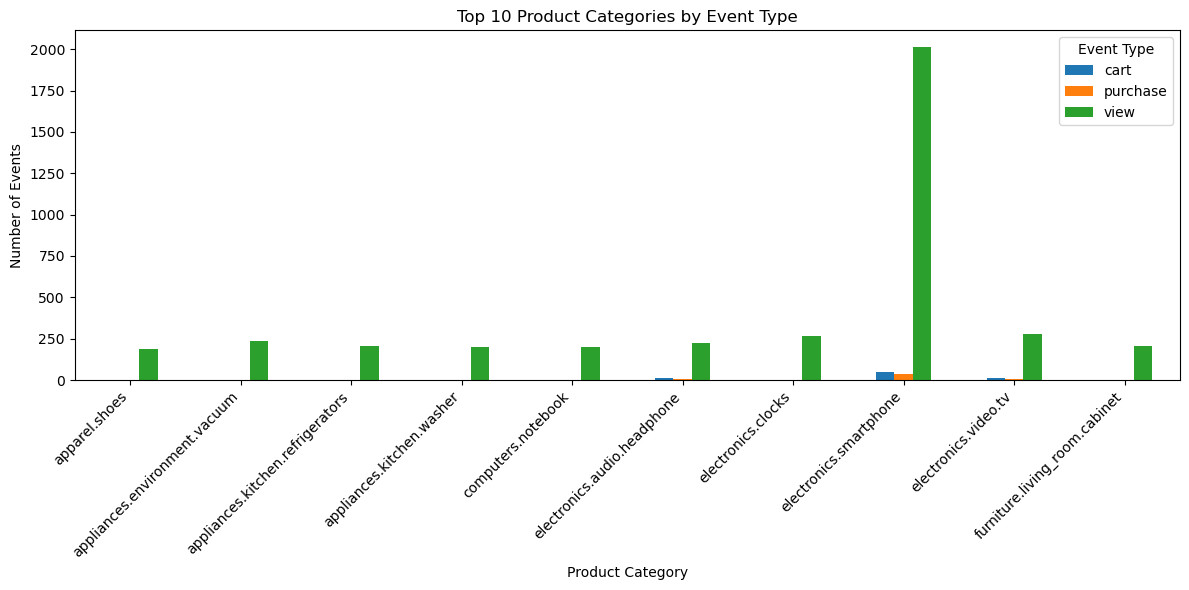

In [40]:
top_categories = (
    data["category_code"]
    .dropna()
    .value_counts()
    .head(10)
    .index
)

category_data = data[data["category_code"].isin(top_categories)]

category_chart = pd.crosstab(
    category_data["category_code"],
    category_data["event_type"]
)

category_chart.plot(kind="bar", figsize=(12, 6))

plt.title("Top 10 Product Categories by Event Type")
plt.xlabel("Product Category")
plt.ylabel("Number of Events")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Event Type")
plt.tight_layout()
plt.show()

In [42]:


category_summary = (
    data.groupby(["category_code", "event_type"], dropna=False)
    .size()
    .reset_index(name="event_count")
)


brand_summary = (
    data.groupby(["brand", "event_type"], dropna=False)
    .size()
    .reset_index(name="event_count")
)


category_summary.to_csv("category_summary.csv", index=False)
brand_summary.to_csv("brand_summary.csv", index=False)

print("Saved category_summary.csv")
print("Saved brand_summary.csv")

Saved category_summary.csv
Saved brand_summary.csv


In [44]:


brand_funnel = pd.crosstab(data["brand"], data["event_type"])


for event in ["view", "cart", "purchase"]:
    if event not in brand_funnel.columns:
        brand_funnel[event] = 0


brand_funnel["View to Cart (%)"] = (
    brand_funnel["cart"] / brand_funnel["view"].replace(0, pd.NA) * 100
).fillna(0).round(2)

brand_funnel["View to Purchase (%)"] = (
    brand_funnel["purchase"] / brand_funnel["view"].replace(0, pd.NA) * 100
).fillna(0).round(2)


display(
    brand_funnel.sort_values("view", ascending=False).head(10)
)

event_type,cart,purchase,view,View to Cart (%),View to Purchase (%)
brand,,,,,
samsung,33,27,962,3.43,2.81
apple,28,18,757,3.70,2.38
xiaomi,15,7,624,2.40,1.12
huawei,1,1,174,0.57,0.57
lucente,0,2,166,0.00,1.20
sony,7,6,141,4.96,4.26
sv,0,1,131,0.00,0.76
bosch,0,1,120,0.00,0.83
rondell,0,0,108,0.00,0.00


### Brand-Level Conversion Analysis

1. Samsung recorded the highest number of views (962) and purchases (27) among the displayed brands.
2. Apple received 757 views and recorded 18 purchases.
3. Sony had the highest view-to-cart event ratio among the displayed brands, at 4.96%, and a view-to-purchase event ratio of 4.26%.
4. Xiaomi received 624 views but recorded 7 purchases.
5. Some brands had views but no recorded cart events or purchases in this sample.

**Recommendation:** Investigate product pricing, availability, reviews, and product-page experience for brands with high browsing activity but relatively few purchases.

**Limitation:** These figures use the first 10,000 rows. They are event-count ratios, not true customer conversion rates, and should not be treated as representative of the full dataset.


In [45]:

brand_funnel_export = brand_funnel.reset_index()


brand_funnel_export.to_csv(
    "brand_funnel_summary.csv",
    index=False
)

print("Brand funnel summary saved successfully!")

Brand funnel summary saved successfully!


In [46]:
funnel_summary = pd.DataFrame({
    "Funnel Stage": [
        "Viewed Products",
        "Viewed + Added to Cart",
        "Viewed + Cart + Purchased"
    ],
    "Sessions": [
        int(view_sessions),
        int(view_cart),
        int(view_cart_purchase)
    ]
})

funnel_summary["Conversion Rate (%)"] = [
    100,
    round(view_cart / view_sessions * 100, 2) if view_sessions else 0,
    round(view_cart_purchase / view_sessions * 100, 2)
    if view_sessions else 0
]

display(funnel_summary)

funnel_summary.to_csv("funnel_summary.csv", index=False)

print("Funnel summary saved successfully!")

,Funnel Stage,Sessions,Conversion Rate (%)
0,Viewed Products,2449,100.00
1,Viewed + Added to Cart,60,2.45
2,Viewed + Cart + Purchased,29,1.18


Funnel summary saved successfully!


In [47]:

import os

files_to_check = [
    "event_summary.csv",
    "category_summary.csv",
    "brand_summary.csv",
    "brand_funnel_summary.csv",
    "funnel_summary.csv"
]

for file in files_to_check:
    if os.path.exists(file):
        print(f"{file} - Saved successfully")
    else:
        print(f"{file} - Not found")

event_summary.csv - Saved successfully
category_summary.csv - Saved successfully
brand_summary.csv - Saved successfully
brand_funnel_summary.csv - Saved successfully
funnel_summary.csv - Saved successfully
